In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
datos_hist = pd.read_csv("Datos/Historicos/results.csv")
goleadores = pd.read_csv("Datos/Historicos/goalscorers.csv")
shootouts = pd.read_csv("Datos/Historicos/shootouts.csv")
nombres = pd.read_csv("Datos/Historicos/former_names.csv")

In [3]:
display(datos_hist.head(), nombres.head())

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


,current,former,start_date,end_date
0,Benin,Dahomey,1959-11-08,1975-11-30
1,Burkina Faso,Upper Volta,1960-04-14,1984-08-04
2,Curaçao,Netherlands Antilles,1957-03-03,2010-10-10
3,Czechoslovakia,Bohemia,1903-04-05,1919-01-01
4,Czechoslovakia,Bohemia and Moravia,1939-01-01,1945-05-01


In [4]:
datos_hist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49477 entries, 0 to 49476
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49477 non-null  object 
 1   home_team   49477 non-null  object 
 2   away_team   49477 non-null  object 
 3   home_score  49425 non-null  float64
 4   away_score  49425 non-null  float64
 5   tournament  49477 non-null  object 
 6   city        49477 non-null  object 
 7   country     49477 non-null  object 
 8   neutral     49477 non-null  bool   
dtypes: bool(1), float64(2), object(6)
memory usage: 3.1+ MB


In [5]:
datos_hist.dropna(subset=['home_score', 'away_score'], inplace=True)

## *Rankings históricos interesantes*

In [7]:
# 1. ESTANDARIZAR LOS NOMBRES DE LOS PAÍSES
# Creamos un diccionario para mapear el nombre antiguo (former) al actual (current)
mapa_nombres = dict(zip(nombres['former'], nombres['current']))

# Aplicamos el reemplazo tanto en la columna de locales como visitantes
datos_hist['home_team'] = datos_hist['home_team'].replace(mapa_nombres)
datos_hist['away_team'] = datos_hist['away_team'].replace(mapa_nombres)


# 2. SEPARAR LOCALES Y VISITANTES PARA EVALUARLOS POR IGUAL
# Extraemos la perspectiva del equipo local
locales = datos_hist[['home_team', 'home_score', 'away_score']].copy()
locales.columns = ['equipo', 'goles_favor', 'goles_contra']

# Extraemos la perspectiva del equipo visitante
visitantes = datos_hist[['away_team', 'away_score', 'home_score']].copy()
visitantes.columns = ['equipo', 'goles_favor', 'goles_contra']

# Unimos ambos dataframes (uno debajo del otro) para tener todos los partidos jugados por cada país
todos_partidos = pd.concat([locales, visitantes], ignore_index=True)

# 3. CALCULAR VICTORIAS, EMPATES Y DERROTAS
# Creamos columnas booleanas que convertimos a 1 (True) y 0 (False)
todos_partidos['victoria'] = (todos_partidos['goles_favor'] > todos_partidos['goles_contra']).astype(int)
todos_partidos['empate'] = (todos_partidos['goles_favor'] == todos_partidos['goles_contra']).astype(int)
todos_partidos['derrota'] = (todos_partidos['goles_favor'] < todos_partidos['goles_contra']).astype(int)
todos_partidos['partidos_jugados'] = 1


# 4. AGRUPAR POR EQUIPO
resumen_equipos = todos_partidos.groupby('equipo').agg({
    'partidos_jugados': 'sum',
    'victoria': 'sum',
    'empate': 'sum',
    'derrota': 'sum',
    'goles_favor': 'sum',
    'goles_contra': 'sum'
}).reset_index()

resumen_equipos["Ratio V/PJ"] = resumen_equipos['victoria']/resumen_equipos['partidos_jugados']

# Ordenamos para ver a los más ganadores de la historia y mostramos
resumen_equipos = resumen_equipos.query('partidos_jugados>=500').sort_values(by='victoria', ascending=False).reset_index(drop=True)
display(resumen_equipos.head(10))

,equipo,partidos_jugados,victoria,empate,derrota,goles_favor,goles_contra,Ratio V/PJ
0,Brazil,1060,672,217,171,2306.0,958.0,0.633962
1,England,1090,625,258,207,2381.0,1041.0,0.573394
2,Germany,1032,600,213,219,2327.0,1199.0,0.581395
3,Argentina,1070,593,257,220,2031.0,1075.0,0.554206
4,Sweden,1102,542,233,327,2176.0,1422.0,0.491833
5,South Korea,1008,539,252,217,1794.0,915.0,0.534722
6,Mexico,1004,515,231,258,1769.0,1054.0,0.512948
7,France,936,478,195,263,1718.0,1210.0,0.510684
8,Italy,893,477,243,173,1565.0,876.0,0.534155
9,Hungary,1006,472,222,312,2011.0,1483.0,0.469185


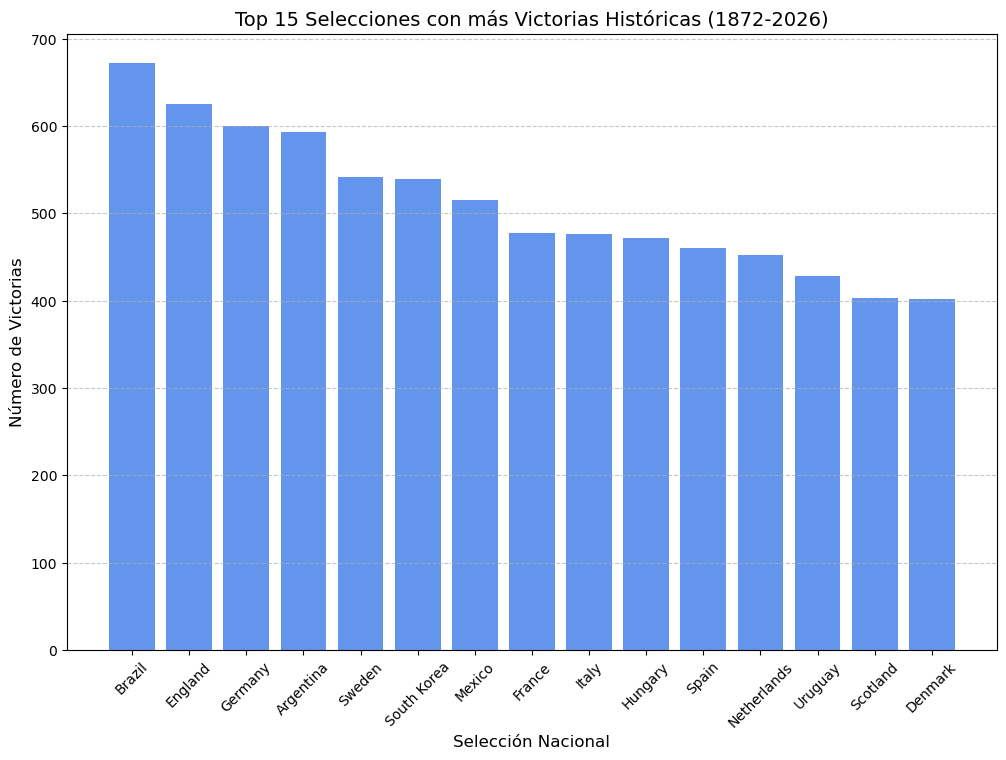

In [8]:
top_15 = resumen_equipos.head(15)

plt.figure(figsize=(12, 8))

plt.bar(top_15['equipo'], top_15['victoria'], color='cornflowerblue')

plt.title('Top 15 Selecciones con más Victorias Históricas (1872-2026)', fontsize=14)
plt.xlabel('Selección Nacional', fontsize=12)
plt.ylabel('Número de Victorias', fontsize=12)

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

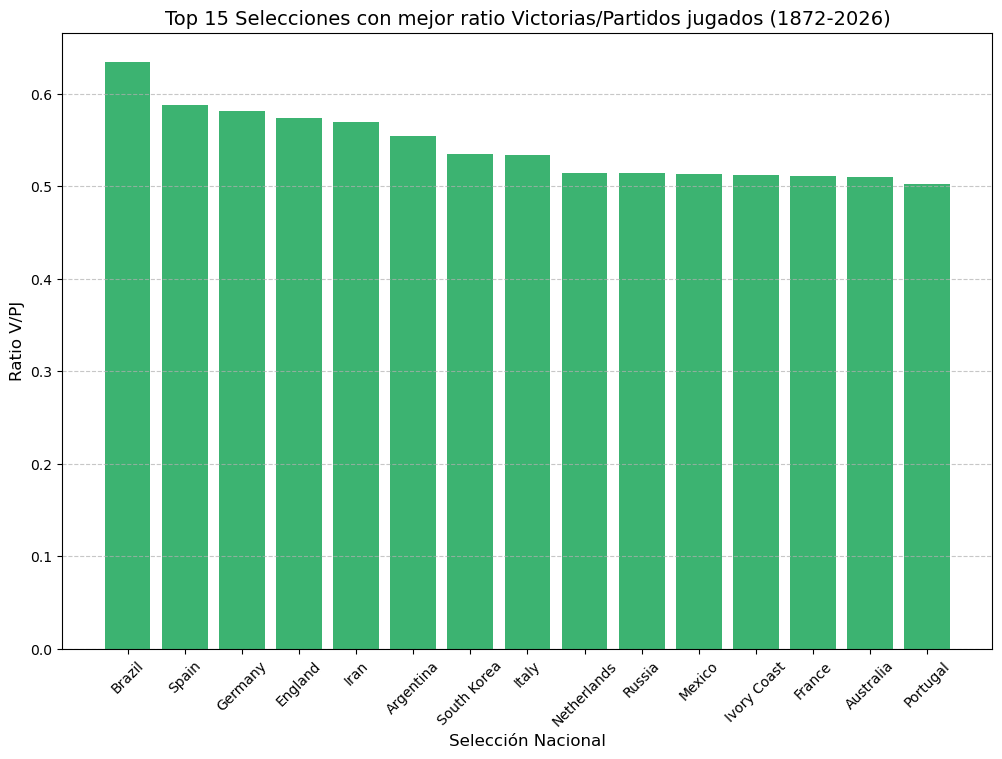

In [9]:
top_15 = resumen_equipos.sort_values(by='Ratio V/PJ', ascending=False).reset_index(drop=True).head(15)

plt.figure(figsize=(12, 8))

plt.bar(top_15['equipo'], top_15['Ratio V/PJ'], color='mediumseagreen')

plt.title('Top 15 Selecciones con mejor ratio Victorias/Partidos jugados (1872-2026)', fontsize=14)
plt.xlabel('Selección Nacional', fontsize=12)
plt.ylabel('Ratio V/PJ', fontsize=12)

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## *Filtrado de datos a trabajar*

In [44]:
# 1. CONVERTIR FECHAS Y FILTRAR
# Aseguramos que la columna date sea de tipo datetime
datos_hist['date'] = pd.to_datetime(datos_hist['date'])

# Filtramos desde el 1 de enero de 2014
datos_recientes = datos_hist[datos_hist['date'] >= '2014-01-01'].copy()


# 2. REPETIMOS LA LÓGICA DE SEPARAR LOCALES Y VISITANTES
locales_rec = datos_recientes[['home_team', 'home_score', 'away_score']].copy()
locales_rec.columns = ['equipo', 'goles_favor', 'goles_contra']

visitantes_rec = datos_recientes[['away_team', 'away_score', 'home_score']].copy()
visitantes_rec.columns = ['equipo', 'goles_favor', 'goles_contra']

partidos_recientes = pd.concat([locales_rec, visitantes_rec], ignore_index=True)
partidos_recientes = partidos_recientes.dropna(subset=['goles_favor', 'goles_contra'])


# 3. CALCULAMOS RESULTADOS
partidos_recientes['victoria'] = (partidos_recientes['goles_favor'] > partidos_recientes['goles_contra']).astype(int)
partidos_recientes['empate'] = (partidos_recientes['goles_favor'] == partidos_recientes['goles_contra']).astype(int)
partidos_recientes['derrota'] = (partidos_recientes['goles_favor'] < partidos_recientes['goles_contra']).astype(int)
partidos_recientes['partidos_jugados'] = 1


# 4. AGRUPAMOS POR EQUIPO
resumen_reciente = partidos_recientes.groupby('equipo').agg({
    'partidos_jugados': 'sum',
    'victoria': 'sum',
    'empate': 'sum',
    'derrota': 'sum',
    'goles_favor': 'sum',
    'goles_contra': 'sum'
}).reset_index()


# 5. CREAMOS EL RATIO Y APLICAMOS EL NUEVO FILTRO
resumen_reciente['Ratio V/PJ'] = resumen_reciente['victoria'] / resumen_reciente['partidos_jugados']

resumen_reciente = resumen_reciente.query('partidos_jugados >=80').sort_values(by='victoria', ascending=False).reset_index(drop=True)
ruta_guardado = "datos_modelo_poisson.csv"
resumen_reciente.to_csv(ruta_guardado, index=False, encoding='utf-8-sig')
resumen_reciente.head(10)

,equipo,partidos_jugados,victoria,empate,derrota,goles_favor,goles_contra,Ratio V/PJ
0,Mexico,208,114,48,46,329.0,199.0,0.548077
1,France,162,108,31,23,344.0,139.0,0.666667
2,Argentina,158,105,33,20,315.0,102.0,0.664557
3,Japan,163,102,28,33,372.0,141.0,0.625767
4,United States,188,100,36,52,353.0,194.0,0.531915
5,Belgium,151,100,28,23,366.0,130.0,0.662252
6,Morocco,157,100,35,22,279.0,83.0,0.636943
7,Portugal,157,99,32,26,343.0,124.0,0.630573
8,Brazil,153,99,33,21,310.0,104.0,0.647059
9,England,155,98,32,25,320.0,103.0,0.632258


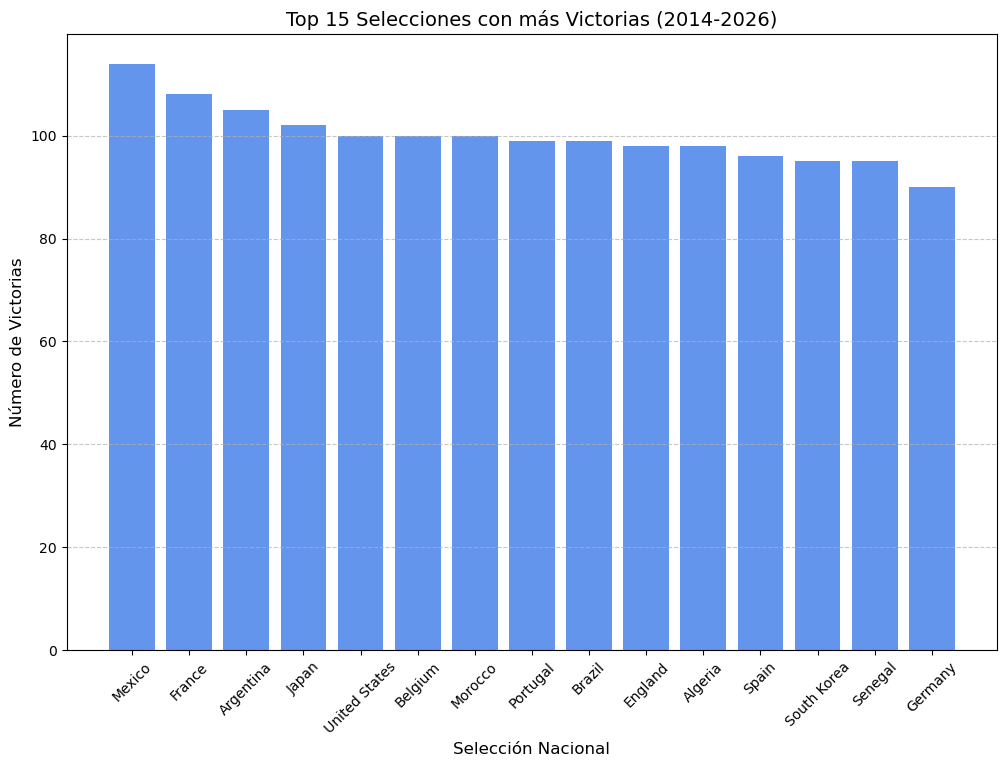

In [12]:
top_15 = resumen_reciente.sort_values(by='victoria', ascending=False).reset_index(drop=True).head(15)

plt.figure(figsize=(12, 8))
plt.bar(top_15['equipo'], top_15['victoria'], color='cornflowerblue')

plt.title('Top 15 Selecciones con más Victorias (2014-2026)', fontsize=14)
plt.xlabel('Selección Nacional', fontsize=12)
plt.ylabel('Número de Victorias', fontsize=12)

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

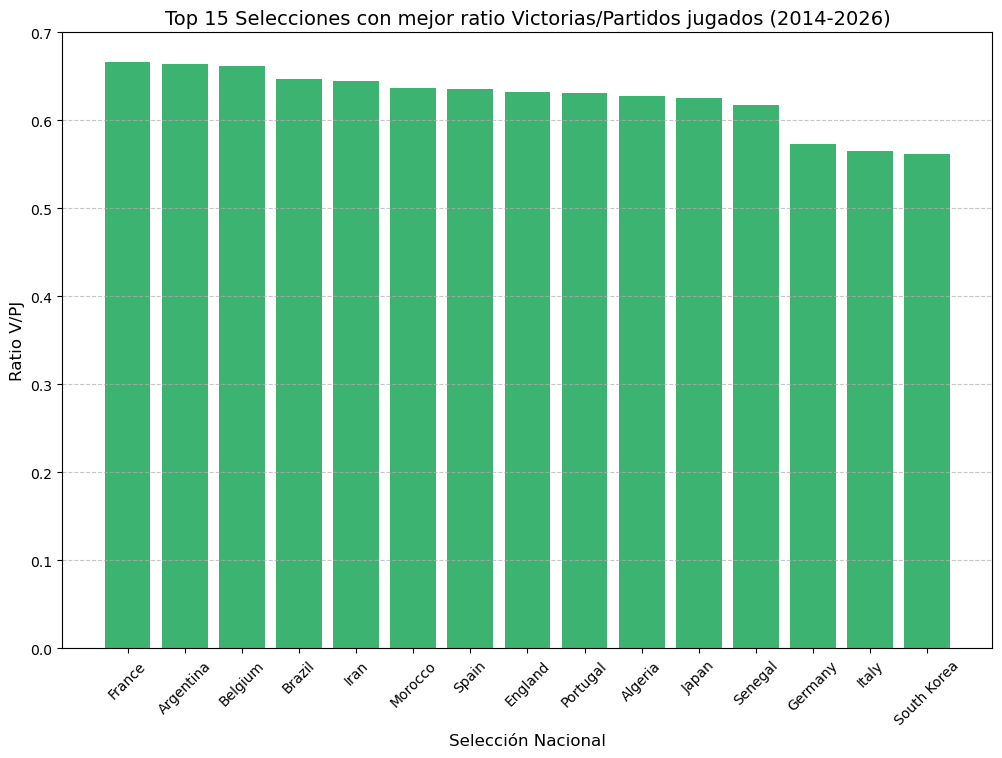

In [13]:
top_15 = resumen_reciente.sort_values(by='Ratio V/PJ', ascending=False).reset_index(drop=True).head(15)

plt.figure(figsize=(12, 8))

plt.bar(top_15['equipo'], top_15['Ratio V/PJ'], color='mediumseagreen')

plt.title('Top 15 Selecciones con mejor ratio Victorias/Partidos jugados (2014-2026)', fontsize=14)
plt.xlabel('Selección Nacional', fontsize=12)
plt.ylabel('Ratio V/PJ', fontsize=12)

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## *Generar score con pesos en los torneos*

In [15]:
# 1. DEFINIMOS NUESTRO SISTEMA DE PESOS
pesos_torneos = {
    'FIFA World Cup': 3.0,
    'UEFA Euro': 2.5,
    'Copa América': 2.5,
    'Confederations Cup': 2.0,
    'CONMEBOL–UEFA Cup of Champions': 2.0,
    'UEFA Nations League': 1.8,
    'FIFA World Cup qualification': 1.5,
    'UEFA Euro qualification': 1.5,
    'African Cup of Nations': 1.5,
    'AFC Asian Cup': 1.5,
    'Gold Cup': 1.5,
    'CONCACAF Nations League': 1.2,
    'Copa América qualification': 1.2,
    'African Cup of Nations qualification': 1.2,
    'Friendly': 0.5
}

# Asignamos el peso; si no está en la lista oficial, vale como amistoso (0.5)
datos_recientes['peso_partido'] = datos_recientes['tournament'].map(pesos_torneos).fillna(0.5)


# 2. SEPARAMOS PERSPECTIVAS (LOCAL Y VISITANTE)
locales_w = datos_recientes[['home_team', 'home_score', 'away_score', 'peso_partido']].copy()
locales_w.columns = ['equipo', 'goles_favor', 'goles_contra', 'peso_partido']

visitantes_w = datos_recientes[['away_team', 'away_score', 'home_score', 'peso_partido']].copy()
visitantes_w.columns = ['equipo', 'goles_favor', 'goles_contra', 'peso_partido']

# Unimos todo y limpiamos valores nulos
partidos_w = pd.concat([locales_w, visitantes_w], ignore_index=True).dropna(subset=['goles_favor', 'goles_contra'])


# 3. CREAMOS LAS COLUMNAS BASE PARA NUESTRAS MÉTRICAS
# Victorias clásicas (1 o 0)
partidos_w['victoria_clasica'] = (partidos_w['goles_favor'] > partidos_w['goles_contra']).astype(int)
partidos_w['partido_jugado'] = 1

# Victorias ponderadas (Suma el peso del torneo si gana, 0 si no)
partidos_w['puntos_victoria_w'] = partidos_w['victoria_clasica'] * partidos_w['peso_partido']
# Puntos totales en disputa (el peso del partido)
partidos_w['partidos_jugados_w'] = partidos_w['peso_partido']


# 4. AGRUPAMOS POR EQUIPO
resumen_final = partidos_w.groupby('equipo').agg({
    'partido_jugado': 'sum',
    'victoria_clasica': 'sum',
    'puntos_victoria_w': 'sum',
    'partidos_jugados_w': 'sum'
}).reset_index()


# 5. CALCULAMOS LAS 3 SÚPER MÉTRICAS
# Métrica 1: Eficiencia General (Tu ratio original)
resumen_final['Ratio_Clasico'] = resumen_final['victoria_clasica'] / resumen_final['partido_jugado']

# Métrica 2: Poder Absoluto (Tu idea de Score)
resumen_final['Score_Poder'] = resumen_final['puntos_victoria_w'] 

# Métrica 3: Jerarquía bajo Presión (Mi idea de Ratio Ponderado)
resumen_final['Indice_Presion'] = resumen_final['puntos_victoria_w'] / resumen_final['partidos_jugados_w']


# 6. FILTRAMOS Y ORDENAMOS
# Aplicamos el filtro de confianza de 80 partidos reales jugados
dataset_modelo = resumen_final.query('partido_jugado >= 80').copy()

# Lo ordenamos por el Score de Poder para ver a los titanes hasta arriba
dataset_modelo = dataset_modelo.sort_values(by='Score_Poder', ascending=False).reset_index(drop=True)

# Mostramos el resultado final
display(dataset_modelo[['equipo', 'partido_jugado', 'Ratio_Clasico', 'Score_Poder', 'Indice_Presion']].head(15))

,equipo,partido_jugado,Ratio_Clasico,Score_Poder,Indice_Presion
0,France,162,0.666667,160.3,0.658587
1,Argentina,158,0.664557,153.5,0.631687
2,Belgium,151,0.662252,153.4,0.663208
3,Portugal,157,0.630573,142.6,0.603215
4,Spain,151,0.635762,142.3,0.617354
5,England,155,0.632258,142.0,0.601185
6,Germany,157,0.573248,135.9,0.593969
7,Mexico,208,0.548077,134.4,0.558836
8,Brazil,153,0.647059,132.0,0.593258
9,Netherlands,146,0.561644,124.9,0.578509


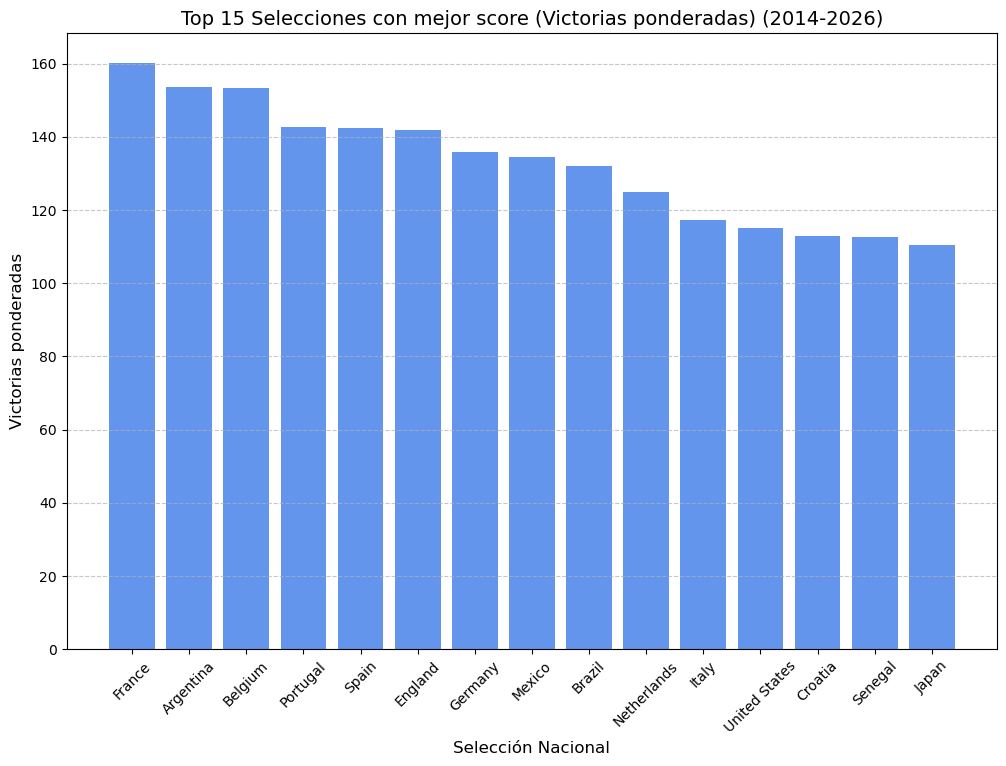

In [16]:
top_15 = dataset_modelo.sort_values(by='Score_Poder', ascending=False).reset_index(drop=True).head(15)

# 2. Ajustamos el tamaño del lienzo (ancho, alto)
plt.figure(figsize=(12, 8))

# 3. Hacemos el gráfico. Pasamos el eje X (equipos) y el eje Y (victorias) separados
plt.bar(top_15['equipo'], top_15['Score_Poder'], color='cornflowerblue')

# 4. Agregamos títulos y etiquetas para darle contexto
plt.title('Top 15 Selecciones con mejor score (Victorias ponderadas) (2014-2026)', fontsize=14)
plt.xlabel('Selección Nacional', fontsize=12)
plt.ylabel('Victorias ponderadas', fontsize=12)

# 5. Rotamos las etiquetas del eje X a 45 grados para que los nombres no se empalmen
plt.xticks(rotation=45)

# 6. Le ponemos una cuadrícula de fondo solo al eje Y para facilitar la lectura
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 7. Mostramos la gráfica
plt.show()

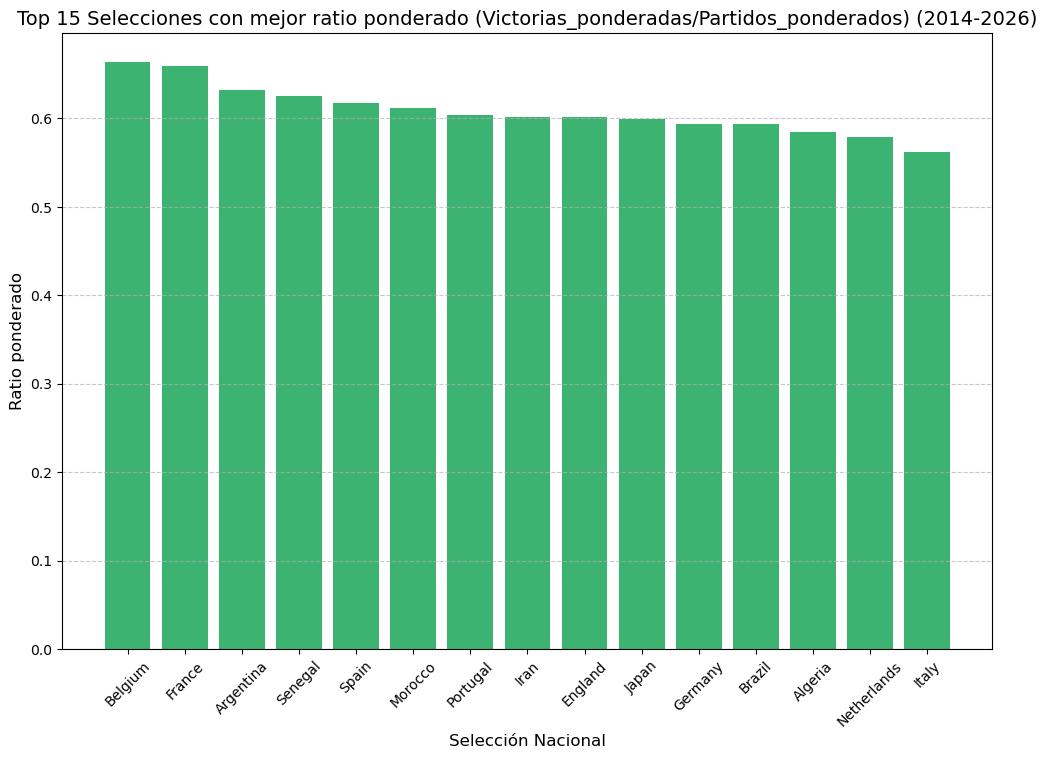

In [17]:
top_15 = dataset_modelo.sort_values(by='Indice_Presion', ascending=False).reset_index(drop=True).head(15)

# 2. Ajustamos el tamaño del lienzo (ancho, alto)
plt.figure(figsize=(12, 8))

# 3. Hacemos el gráfico. Pasamos el eje X (equipos) y el eje Y (victorias) separados
plt.bar(top_15['equipo'], top_15['Indice_Presion'], color='mediumseagreen')

# 4. Agregamos títulos y etiquetas para darle contexto
plt.title('Top 15 Selecciones con mejor ratio ponderado (Victorias_ponderadas/Partidos_ponderados) (2014-2026)', fontsize=14)
plt.xlabel('Selección Nacional', fontsize=12)
plt.ylabel('Ratio ponderado', fontsize=12)

# 5. Rotamos las etiquetas del eje X a 45 grados para que los nombres no se empalmen
plt.xticks(rotation=45)

# 6. Le ponemos una cuadrícula de fondo solo al eje Y para facilitar la lectura
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 7. Mostramos la gráfica
plt.show()

## Datos dinámicos

In [19]:
datos_dinam = pd.read_csv("Datos/Dinámicos/forma_actual_mundial_2026.csv")
datos_dinam.head()

,Equipo,PTS,Puntos,Promedio_Rivales,Forma_Actual
0,Norway,6,1606.48,1650.666667,4.95
1,Colombia,6,1727.42,1557.316667,4.67
2,France,6,1894.40,1554.693333,4.66
3,United States,6,1709.59,1550.690000,4.65
4,Argentina,6,1901.93,1510.506667,4.53


## Fusión de datos

In [21]:
dataset_modelo['equipo'] = dataset_modelo['equipo'].replace({'Curaçao':'Curacao'})
datos_dinam = datos_dinam.rename(columns={'Equipo': 'equipo'})

In [22]:
print("Iniciando la fusión")

# 1. Estandarizamos el nombre de la columna clave para que coincidan perfectamente

# 2. Hacemos la fusión (Merge)
# Usamos how='inner' para asegurarnos de que el modelo solo se entrene 
# con los 48 equipos que realmente van a participar en este Mundial.
dataset_final = pd.merge(dataset_modelo, datos_dinam, on='equipo', how='inner')

# 3. (Opcional) Ordenar un poco las columnas si quieres que la métrica quede al principio o al final
# Pero Pandas por defecto pondrá las nuevas columnas a la derecha, lo cual es perfecto.

print("Vista previa del Dataset Definitivo:")
display(dataset_final.head())

# 4. Exportar el Dataset Listo para Entrenar
ruta_guardado = 'dataset_entrenamiento_mundial_2026.csv'

# index=False evita que se guarde la columna de índices (0, 1, 2...)
dataset_final.to_csv(ruta_guardado, index=False, encoding='utf-8-sig')

print(f'El archivo maestro ha sido guardado como {ruta_guardado}')

Iniciando la fusión
Vista previa del Dataset Definitivo:


,equipo,partido_jugado,victoria_clasica,puntos_victoria_w,partidos_jugados_w,Ratio_Clasico,Score_Poder,Indice_Presion,PTS,Puntos,Promedio_Rivales,Forma_Actual
0,France,162,108,160.3,243.4,0.666667,160.3,0.658587,6,1894.40,1554.693333,4.66
1,Argentina,158,105,153.5,243.0,0.664557,153.5,0.631687,6,1901.93,1510.506667,4.53
2,Belgium,151,100,153.4,231.3,0.662252,153.4,0.663208,2,1727.88,1490.630000,1.49
3,Portugal,157,99,142.6,236.4,0.630573,142.6,0.603215,4,1766.74,1544.210000,3.09
4,Spain,151,96,142.3,230.5,0.635762,142.3,0.617354,4,1864.32,1492.813333,2.99


El archivo maestro ha sido guardado como dataset_entrenamiento_mundial_2026.csv
